# 03 — 5-fold supervised baseline + simple SSL

Итоговый ноутбук для практической части.
Каждый fold уже нормализован отдельно: `mean/std` посчитаны только по train текущего fold.

Сравниваем:

1. `supervised_from_scratch`;
2. `masked_reconstruction_ssl_plus_finetune`;
3. `temporal_permutation_ssl_plus_finetune`.

Оценка: `accuracy`, `macro-F1`, `balanced accuracy`, mean ± std по 5 folds.

In [1]:
from pathlib import Path
import json
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("mps available:", torch.backends.mps.is_available())
print("mps built:", torch.backends.mps.is_built())

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)

torch: 2.11.0
cuda available: False
mps available: True
mps built: True
device: mps


In [2]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [3]:
PROCESSED_DIR = Path("../data/processed").resolve()
LABEL_PATH = PROCESSED_DIR / "sensor0_1s_overlap75_label_mapping.json"

FOLD_PATHS = [
    PROCESSED_DIR / f"sensor0_1s_overlap75_fold{i}.npz"
    for i in range(5)
]

assert PROCESSED_DIR.exists(), f"Missing processed dir: {PROCESSED_DIR}"
assert LABEL_PATH.exists(), f"Missing label mapping: {LABEL_PATH}"

for p in FOLD_PATHS:
    assert p.exists(), f"Missing fold file: {p}"

print("PROCESSED_DIR:", PROCESSED_DIR)
print("LABEL_PATH:", LABEL_PATH)
print("FOLD_PATHS:")
for p in FOLD_PATHS:
    print(" ", p.name)

PROCESSED_DIR: /Users/arsenij/Desktop/kurs-ml-ssl/data/processed
LABEL_PATH: /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/sensor0_1s_overlap75_label_mapping.json
FOLD_PATHS:
  sensor0_1s_overlap75_fold0.npz
  sensor0_1s_overlap75_fold1.npz
  sensor0_1s_overlap75_fold2.npz
  sensor0_1s_overlap75_fold3.npz
  sensor0_1s_overlap75_fold4.npz


In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 0

LR = 1e-3
WEIGHT_DECAY = 1e-4

SUPERVISED_EPOCHS = 20
SSL_EPOCHS = 10
FINETUNE_EPOCHS = 15

N_CHANNELS = 6
WINDOW_SIZE = 52
NUM_CLASSES = 7

FOLDS_TO_RUN = [0, 1, 2, 3, 4]

## 1. Label mapping

In [5]:
with open(LABEL_PATH, "r") as f:
    label_obj = json.load(f)

if "label_to_id" in label_obj:
    label_to_id = {str(k): int(v) for k, v in label_obj["label_to_id"].items()}
else:
    label_to_id = {str(k): int(v) for k, v in label_obj.items()}

id_to_label = {v: k for k, v in label_to_id.items()}
class_names = [id_to_label[i] for i in range(len(id_to_label))]

print("label_to_id:")
for label, idx in label_to_id.items():
    print(f"  {label}: {idx}")

print("class_names:", class_names)

assert len(class_names) == NUM_CLASSES

label_to_id:
  carioca_left: 0
  carioca_right: 1
  heel_to_butt: 2
  high_knee_run: 3
  running: 4
  sideskips_left: 5
  sideskips_right: 6
class_names: ['carioca_left', 'carioca_right', 'heel_to_butt', 'high_knee_run', 'running', 'sideskips_left', 'sideskips_right']


В этом блоке загружается соответствие между строковыми названиями классов и числовыми id. Это нужно, потому что PyTorch `CrossEntropyLoss` работает с целочисленными метками классов.

Mapping позволяет не только обучать модель, но и интерпретировать результаты: confusion matrix, предсказания и метрики можно обратно связать с исходными названиями движений, например `running`, `high_knee_run`, `sideskips_left`.

## 2. Dataset classes

In [6]:
class WindowDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]


class MaskedReconstructionDataset(Dataset):
    def __init__(self, X, mask_ratio=0.20):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        target = x.clone()

        C, T = x.shape
        n_mask = max(1, int(T * self.mask_ratio))
        mask_idx = torch.randperm(T)[:n_mask]

        mask = torch.zeros(T, dtype=torch.bool)
        mask[mask_idx] = True

        x[:, mask] = 0.0

        return x, target, mask


class TemporalPermutationDataset(Dataset):
    def __init__(self, X, n_segments=4, p_permute=0.5):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.n_segments = n_segments
        self.p_permute = p_permute

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()

        if random.random() > self.p_permute:
            return x, torch.tensor(0.0)

        C, T = x.shape
        seg_len = T // self.n_segments
        usable_T = seg_len * self.n_segments

        segments = [
            x[:, i * seg_len:(i + 1) * seg_len]
            for i in range(self.n_segments)
        ]

        perm = torch.randperm(self.n_segments)
        if torch.equal(perm, torch.arange(self.n_segments)):
            perm = torch.roll(perm, shifts=1)

        x_perm = torch.cat([segments[int(i)] for i in perm], dim=1)

        if usable_T < T:
            x_perm = torch.cat([x_perm, x[:, usable_T:]], dim=1)

        return x_perm, torch.tensor(1.0)


def make_loaders(X_train, X_val, y_train, y_val):
    train_loader = DataLoader(
        WindowDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    val_loader = DataLoader(
        WindowDataset(X_val, y_val),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    ssl_rec_loader = DataLoader(
        MaskedReconstructionDataset(X_train, mask_ratio=0.20),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    ssl_perm_loader = DataLoader(
        TemporalPermutationDataset(X_train, n_segments=4, p_permute=0.5),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    return train_loader, val_loader, ssl_rec_loader, ssl_perm_loader

Здесь определены dataset-классы для трёх режимов обучения.

`WindowDataset` используется для supervised classification и fine-tuning. Он возвращает пару `(x, y)`, где `x` — IMU-окно формы `[6, 52]`, а `y` — id класса.

`MaskedReconstructionDataset` используется для SSL-задачи восстановления. Он случайно маскирует часть timestep внутри окна, зануляет их во входе и возвращает исходный сигнал как target. Модель должна восстановить значения на замаскированных позициях.

`TemporalPermutationDataset` используется для SSL-задачи определения нарушения временного порядка. Окно либо остаётся в исходном порядке, либо разбивается на сегменты и перемешивается. Модель должна предсказать, был ли порядок изменён.

Функция `make_loaders` создаёт DataLoader для supervised, validation и двух SSL-задач. Важно, что SSL DataLoader строится только на `X_train`, без использования validation-данных.

## 3. Models

In [7]:
class FCNEncoder(nn.Module):
    def __init__(self, in_channels=6, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        h = self.net(x)
        z = h.mean(dim=-1)
        return z, h


class FCNClassifier(nn.Module):
    def __init__(self, num_classes=7, in_channels=6, hidden_dim=128):
        super().__init__()
        self.encoder = FCNEncoder(in_channels=in_channels, hidden_dim=hidden_dim)
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        z, _ = self.encoder(x)
        logits = self.head(z)
        return logits


class MaskedReconstructionModel(nn.Module):
    def __init__(self, in_channels=6, hidden_dim=128):
        super().__init__()
        self.encoder = FCNEncoder(in_channels=in_channels, hidden_dim=hidden_dim)
        self.decoder = nn.Sequential(
            nn.Conv1d(hidden_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, in_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        _, h = self.encoder(x)
        rec = self.decoder(h)
        return rec


class TemporalPermutationModel(nn.Module):
    def __init__(self, in_channels=6, hidden_dim=128):
        super().__init__()
        self.encoder = FCNEncoder(in_channels=in_channels, hidden_dim=hidden_dim)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z, _ = self.encoder(x)
        logit = self.head(z).squeeze(-1)
        return logit

В эксперименте используется одна базовая архитектура encoder — 1D-CNN/FCN. Она обрабатывает временные ряды в формате `[batch, channels, time]`, то есть `[B, 6, 52]`.

Encoder состоит из нескольких `Conv1d` слоёв с `BatchNorm1d` и `ReLU`. После свёрток применяется усреднение по временной оси, чтобы получить один embedding-вектор окна.

Для разных режимов обучения используются разные головы:

`FCNClassifier` добавляет classification head и используется для supervised baseline и fine-tuning.

`MaskedReconstructionModel` добавляет reconstruction head, который восстанавливает сигнал по временной оси.

`TemporalPermutationModel` добавляет binary head, который предсказывает, был ли нарушен временной порядок сегментов.

Такое разделение позволяет честно сравнивать подходы: encoder один и тот же, меняется только pretext-задача и head.

## 4. Train and evaluation functions

In [8]:
@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()

    losses = []
    y_true_all = []
    y_pred_all = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        pred = logits.argmax(dim=1)

        losses.append(loss.item() * xb.size(0))
        y_true_all.append(yb.detach().cpu().numpy())
        y_pred_all.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    return {
        "loss": sum(losses) / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_classifier(model, train_loader, val_loader, epochs, run_name):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_metrics = None
    best_macro_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        train_loss = total_loss / total_n
        val_metrics = evaluate_classifier(model, val_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        })

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = copy.deepcopy(val_metrics)

        print(
            f"[{run_name}] epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"acc={val_metrics['accuracy']:.4f} | "
            f"macro_f1={val_metrics['macro_f1']:.4f} | "
            f"bal_acc={val_metrics['balanced_accuracy']:.4f}"
        )

    model.load_state_dict(best_state)
    return model, best_metrics, pd.DataFrame(history)


def train_masked_reconstruction(model, loader, epochs, run_name):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_n = 0

        for x_masked, target, mask in loader:
            x_masked = x_masked.to(DEVICE)
            target = target.to(DEVICE)
            mask = mask.to(DEVICE)

            rec = model(x_masked)
            mask_3d = mask.unsqueeze(1).expand_as(target)
            loss = F.mse_loss(rec[mask_3d], target[mask_3d])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x_masked.size(0)
            total_n += x_masked.size(0)

        ssl_loss = total_loss / total_n
        history.append({"epoch": epoch, "ssl_loss": ssl_loss})

        print(f"[{run_name}] epoch {epoch:03d} | ssl_loss={ssl_loss:.6f}")

    return model, pd.DataFrame(history)


def train_temporal_permutation(model, loader, epochs, run_name):
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_n = 0

        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

        ssl_loss = total_loss / total_n
        history.append({"epoch": epoch, "ssl_loss": ssl_loss})

        print(f"[{run_name}] epoch {epoch:03d} | ssl_loss={ssl_loss:.6f}")

    return model, pd.DataFrame(history)


def plot_confusion(metrics, title):
    cm = confusion_matrix(metrics["y_true"], metrics["y_pred"], labels=list(range(NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

В этом блоке определены функции обучения и оценки.

`evaluate_classifier` считает loss, accuracy, macro-F1 и balanced accuracy на validation set. Также сохраняются истинные и предсказанные метки, чтобы потом можно было построить confusion matrix.

`train_classifier` обучает классификатор по `CrossEntropyLoss`. Во время обучения сохраняется лучшая версия модели по `val_macro_f1`. Это важно, потому что последняя эпоха не всегда даёт лучшее качество на validation.

`train_masked_reconstruction` обучает модель восстанавливать замаскированные timestep. Loss считается только на замаскированных позициях, чтобы модель действительно училась восстанавливать скрытые части сигнала.

`train_temporal_permutation` обучает модель отличать исходный порядок сегментов от перемешанного. Это бинарная SSL-задача, поэтому используется `BCEWithLogitsLoss`.

Функция `plot_confusion` строит confusion matrix для анализа ошибок классификации по классам.

## 5. Fold runner

In [9]:
def load_fold(fold_path):
    data = np.load(fold_path, allow_pickle=True)

    X_train = data["X_train"].astype(np.float32)
    X_val = data["X_val"].astype(np.float32)

    y_train = data["y_train"].astype(np.int64)
    y_val = data["y_val"].astype(np.int64)

    subjects_train = data["subjects_train"].astype(str)
    subjects_val = data["subjects_val"].astype(str)

    groups_train = data["groups_train"].astype(str)
    groups_val = data["groups_val"].astype(str)

    fold_id = int(np.array(data["fold_id"]).item()) if "fold_id" in data.files else None

    assert set(groups_train).isdisjoint(set(groups_val))
    assert X_train.shape[1:] == (N_CHANNELS, WINDOW_SIZE)
    assert X_val.shape[1:] == (N_CHANNELS, WINDOW_SIZE)

    return {
        "fold_id": fold_id,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "subjects_train": subjects_train,
        "subjects_val": subjects_val,
        "groups_train": groups_train,
        "groups_val": groups_val,
    }


def run_fold(fold_path, fold_id, plot_cm=False):
    print("=" * 90)
    print(f"FOLD {fold_id}")
    print("=" * 90)

    fold = load_fold(fold_path)

    X_train = fold["X_train"]
    X_val = fold["X_val"]
    y_train = fold["y_train"]
    y_val = fold["y_val"]

    print("X_train:", X_train.shape)
    print("X_val:  ", X_val.shape)
    print("y_train:", y_train.shape)
    print("y_val:  ", y_val.shape)
    print("train subjects:", sorted(np.unique(fold["subjects_train"]).tolist()))
    print("val subjects:  ", sorted(np.unique(fold["subjects_val"]).tolist()))
    print("train groups:", sorted(np.unique(fold["groups_train"]).tolist()))
    print("val groups:  ", sorted(np.unique(fold["groups_val"]).tolist()))
    print("group leakage check:", set(fold["groups_train"]).isdisjoint(set(fold["groups_val"])))

    train_loader, val_loader, ssl_rec_loader, ssl_perm_loader = make_loaders(
        X_train, X_val, y_train, y_val
    )

    fold_rows = []
    fold_histories = {}

    # 1. Supervised baseline
    set_seed(SEED + fold_id)

    supervised_model = FCNClassifier(num_classes=NUM_CLASSES, in_channels=N_CHANNELS)

    supervised_model, supervised_metrics, supervised_history = train_classifier(
        supervised_model,
        train_loader,
        val_loader,
        epochs=SUPERVISED_EPOCHS,
        run_name=f"fold{fold_id}_supervised",
    )

    fold_rows.append({
        "fold": fold_id,
        "model": "supervised_from_scratch",
        "loss": supervised_metrics["loss"],
        "accuracy": supervised_metrics["accuracy"],
        "macro_f1": supervised_metrics["macro_f1"],
        "balanced_accuracy": supervised_metrics["balanced_accuracy"],
    })

    fold_histories["supervised"] = supervised_history

    if plot_cm:
        plot_confusion(supervised_metrics, f"Fold {fold_id} | supervised baseline")

    # 2. Masked reconstruction SSL + fine-tuning
    set_seed(SEED + fold_id)

    rec_ssl_model = MaskedReconstructionModel(in_channels=N_CHANNELS)

    rec_ssl_model, rec_ssl_history = train_masked_reconstruction(
        rec_ssl_model,
        ssl_rec_loader,
        epochs=SSL_EPOCHS,
        run_name=f"fold{fold_id}_masked_reconstruction_ssl",
    )

    rec_ft_model = FCNClassifier(num_classes=NUM_CLASSES, in_channels=N_CHANNELS)
    rec_ft_model.encoder.load_state_dict(rec_ssl_model.encoder.state_dict())

    rec_ft_model, rec_ft_metrics, rec_ft_history = train_classifier(
        rec_ft_model,
        train_loader,
        val_loader,
        epochs=FINETUNE_EPOCHS,
        run_name=f"fold{fold_id}_masked_rec_finetune",
    )

    fold_rows.append({
        "fold": fold_id,
        "model": "masked_reconstruction_ssl_plus_finetune",
        "loss": rec_ft_metrics["loss"],
        "accuracy": rec_ft_metrics["accuracy"],
        "macro_f1": rec_ft_metrics["macro_f1"],
        "balanced_accuracy": rec_ft_metrics["balanced_accuracy"],
    })

    fold_histories["masked_reconstruction_ssl"] = rec_ssl_history
    fold_histories["masked_reconstruction_finetune"] = rec_ft_history

    if plot_cm:
        plot_confusion(rec_ft_metrics, f"Fold {fold_id} | masked reconstruction + fine-tuning")

    # 3. Temporal permutation SSL + fine-tuning
    set_seed(SEED + fold_id)

    perm_ssl_model = TemporalPermutationModel(in_channels=N_CHANNELS)

    perm_ssl_model, perm_ssl_history = train_temporal_permutation(
        perm_ssl_model,
        ssl_perm_loader,
        epochs=SSL_EPOCHS,
        run_name=f"fold{fold_id}_temporal_permutation_ssl",
    )

    perm_ft_model = FCNClassifier(num_classes=NUM_CLASSES, in_channels=N_CHANNELS)
    perm_ft_model.encoder.load_state_dict(perm_ssl_model.encoder.state_dict())

    perm_ft_model, perm_ft_metrics, perm_ft_history = train_classifier(
        perm_ft_model,
        train_loader,
        val_loader,
        epochs=FINETUNE_EPOCHS,
        run_name=f"fold{fold_id}_temporal_perm_finetune",
    )

    fold_rows.append({
        "fold": fold_id,
        "model": "temporal_permutation_ssl_plus_finetune",
        "loss": perm_ft_metrics["loss"],
        "accuracy": perm_ft_metrics["accuracy"],
        "macro_f1": perm_ft_metrics["macro_f1"],
        "balanced_accuracy": perm_ft_metrics["balanced_accuracy"],
    })

    fold_histories["temporal_permutation_ssl"] = perm_ssl_history
    fold_histories["temporal_permutation_finetune"] = perm_ft_history

    if plot_cm:
        plot_confusion(perm_ft_metrics, f"Fold {fold_id} | temporal permutation + fine-tuning")

    return pd.DataFrame(fold_rows), fold_histories

Функция `load_fold` загружает один `.npz` fold-файл и проверяет корректность данных. Особенно важна проверка `groups_train` и `groups_val`: они не должны пересекаться. Это гарантирует, что один и тот же участник или объединённая группа не попали одновременно в train и validation.

Функция `run_fold` выполняет полный эксперимент на одном fold. Для каждого fold модели создаются заново с нуля. Это принципиально важно: нельзя обучить модель на fold 0, а потом продолжать обучение на fold 1, потому что тогда validation-группы предыдущих folds попадут в обучение следующих.

На каждом fold обучаются три варианта:

1. supervised baseline с нуля;
2. masked reconstruction SSL + fine-tuning;
3. temporal permutation SSL + fine-tuning.

Для SSL-подходов сначала обучается encoder на pretext-задаче без labels, затем encoder переносится в классификатор и дообучается на размеченных данных текущего train fold.

## 6. Run 5 folds

FOLD 0
X_train: (4046, 6, 52)
X_val:   (1224, 6, 52)
y_train: (4046,)
y_val:   (1224,)
train subjects: ['participant_1', 'participant_10', 'participant_11', 'participant_13', 'participant_14', 'participant_15', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_3', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']
val subjects:   ['participant_12', 'participant_12_2', 'participant_16', 'participant_20', 'participant_4']
train groups: ['participant_1', 'participant_10', 'participant_11', 'participant_13', 'participant_14', 'participant_15', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_3', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']
val groups:   ['participant_12', 'participant_16', 'participant_20', 'participant_4']
group leakage check: True
[fold0_supervised] epoch 001 | train_loss=0.8748 | val_loss=1.1059 | acc=0.5784 | macro_f1=0.5632 | b

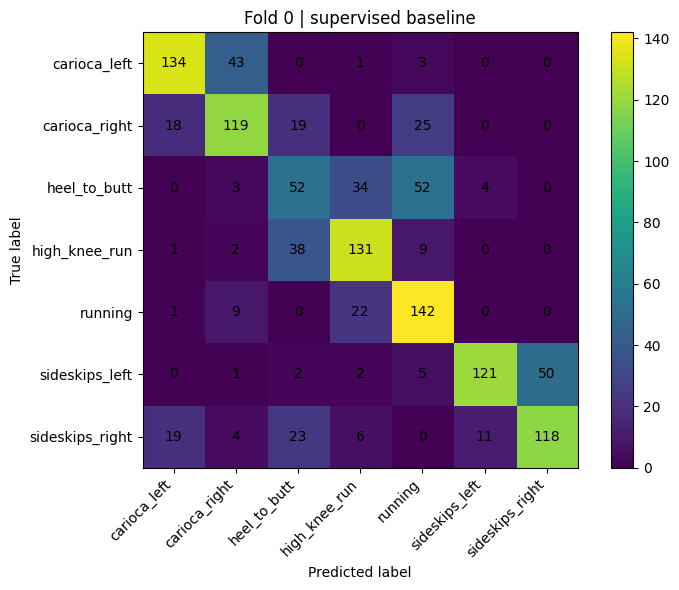

[fold0_masked_reconstruction_ssl] epoch 001 | ssl_loss=0.259819
[fold0_masked_reconstruction_ssl] epoch 002 | ssl_loss=0.158771
[fold0_masked_reconstruction_ssl] epoch 003 | ssl_loss=0.141541
[fold0_masked_reconstruction_ssl] epoch 004 | ssl_loss=0.128345
[fold0_masked_reconstruction_ssl] epoch 005 | ssl_loss=0.121522
[fold0_masked_reconstruction_ssl] epoch 006 | ssl_loss=0.111355
[fold0_masked_reconstruction_ssl] epoch 007 | ssl_loss=0.107529
[fold0_masked_reconstruction_ssl] epoch 008 | ssl_loss=0.098710
[fold0_masked_reconstruction_ssl] epoch 009 | ssl_loss=0.097752
[fold0_masked_reconstruction_ssl] epoch 010 | ssl_loss=0.094448
[fold0_masked_rec_finetune] epoch 001 | train_loss=1.0230 | val_loss=1.4064 | acc=0.4412 | macro_f1=0.4240 | bal_acc=0.4380
[fold0_masked_rec_finetune] epoch 002 | train_loss=0.2463 | val_loss=1.1621 | acc=0.5588 | macro_f1=0.5444 | bal_acc=0.5518
[fold0_masked_rec_finetune] epoch 003 | train_loss=0.0971 | val_loss=1.1104 | acc=0.5825 | macro_f1=0.5651 | bal

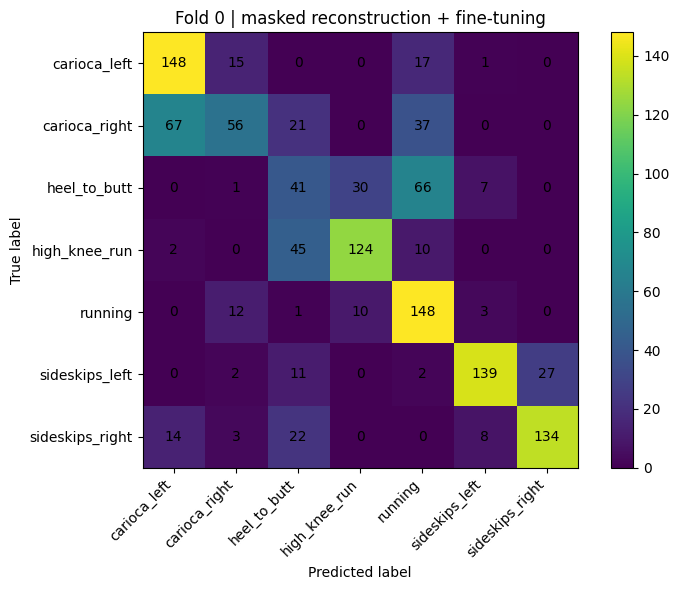

[fold0_temporal_permutation_ssl] epoch 001 | ssl_loss=0.611382
[fold0_temporal_permutation_ssl] epoch 002 | ssl_loss=0.470200
[fold0_temporal_permutation_ssl] epoch 003 | ssl_loss=0.384931
[fold0_temporal_permutation_ssl] epoch 004 | ssl_loss=0.348487
[fold0_temporal_permutation_ssl] epoch 005 | ssl_loss=0.297531
[fold0_temporal_permutation_ssl] epoch 006 | ssl_loss=0.299624
[fold0_temporal_permutation_ssl] epoch 007 | ssl_loss=0.264547
[fold0_temporal_permutation_ssl] epoch 008 | ssl_loss=0.241116
[fold0_temporal_permutation_ssl] epoch 009 | ssl_loss=0.243043
[fold0_temporal_permutation_ssl] epoch 010 | ssl_loss=0.227844
[fold0_temporal_perm_finetune] epoch 001 | train_loss=0.9879 | val_loss=1.2878 | acc=0.4657 | macro_f1=0.4602 | bal_acc=0.4610
[fold0_temporal_perm_finetune] epoch 002 | train_loss=0.2271 | val_loss=0.9915 | acc=0.6119 | macro_f1=0.6001 | bal_acc=0.6036
[fold0_temporal_perm_finetune] epoch 003 | train_loss=0.0866 | val_loss=1.0163 | acc=0.6005 | macro_f1=0.5948 | bal_

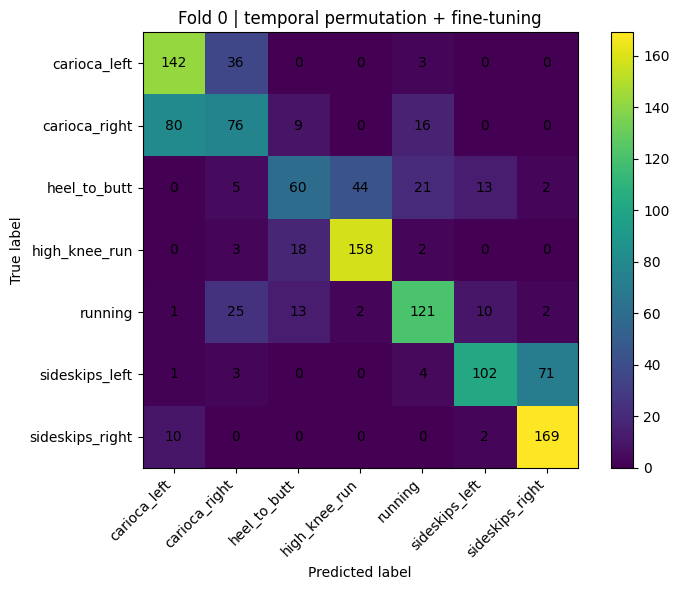

FOLD 1
X_train: (4255, 6, 52)
X_val:   (1015, 6, 52)
y_train: (4255,)
y_val:   (1015,)
train subjects: ['participant_10', 'participant_11', 'participant_12', 'participant_12_2', 'participant_13', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_20', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']
val subjects:   ['participant_1', 'participant_14', 'participant_15', 'participant_2']
train groups: ['participant_10', 'participant_11', 'participant_12', 'participant_13', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_20', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']
val groups:   ['participant_1', 'participant_14', 'participant_15', 'participant_2']
group leakage check: True
[fold1_supervised] epoch 001 | train_loss=0.9127 | val_loss=0.7998 | acc=0.7399 | macro_f1=0.7370 | b

In [10]:
all_results = []
all_histories = {}

start_time = time.time()

for fold_id in FOLDS_TO_RUN:
    fold_path = FOLD_PATHS[fold_id]

    fold_results, fold_histories = run_fold(
        fold_path=fold_path,
        fold_id=fold_id,
        plot_cm=(fold_id == FOLDS_TO_RUN[0]),
    )

    all_results.append(fold_results)
    all_histories[fold_id] = fold_histories

elapsed_min = (time.time() - start_time) / 60
print(f"Total time: {elapsed_min:.2f} min")

Здесь запускается основной цикл эксперимента по всем пяти folds. Для каждого fold выполняется полный pipeline обучения трёх моделей, а результаты сохраняются в список `all_results`.

Важно, что каждый fold использует свои train и validation groups. Поэтому итоговая оценка показывает не качество на одном случайном split, а среднюю устойчивость метода на разных наборах участников.

Время выполнения показывает, что текущий MVP достаточно лёгкий и может быть быстро воспроизведён на Mac с MPS.

## 7. Results by fold

In [11]:
results = pd.concat(all_results, ignore_index=True)
results

,fold,model,loss,accuracy,macro_f1,balanced_accuracy
0,0,supervised_from_scratch,1.074862,0.667484,0.659221,0.659529
1,0,masked_reconstruction_ssl_plus_finetune,1.179217,0.645425,0.627783,0.636254
2,0,temporal_permutation_ssl_plus_finetune,0.903875,0.676471,0.660604,0.669112
3,1,supervised_from_scratch,0.407879,0.903448,0.902254,0.903448
4,1,masked_reconstruction_ssl_plus_finetune,0.496055,0.907389,0.905049,0.907389
5,1,temporal_permutation_ssl_plus_finetune,0.614532,0.907389,0.903903,0.907389
6,2,supervised_from_scratch,0.141230,0.949704,0.949075,0.949754
7,2,masked_reconstruction_ssl_plus_finetune,0.242934,0.945759,0.945016,0.945779
8,2,temporal_permutation_ssl_plus_finetune,0.135209,0.959566,0.959417,0.959606
9,3,supervised_from_scratch,0.525476,0.884044,0.884959,0.884182


## 8. Mean ± std summary

In [12]:
summary_flat = results.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    balanced_accuracy_mean=("balanced_accuracy", "mean"),
    balanced_accuracy_std=("balanced_accuracy", "std"),
).reset_index()

summary_flat

,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,masked_reconstruction_ssl_plus_finetune,0.829705,0.116738,0.825588,0.123287,0.827897,0.120382
1,supervised_from_scratch,0.842642,0.110360,0.841330,0.113247,0.841089,0.113554
2,temporal_permutation_ssl_plus_finetune,0.855327,0.114141,0.851693,0.119802,0.853881,0.117056


## 9. Save results

In [13]:
results_path = PROCESSED_DIR / "03_results_5fold_by_fold.csv"
summary_path = PROCESSED_DIR / "03_results_5fold_summary.csv"

results.to_csv(results_path, index=False)
summary_flat.to_csv(summary_path, index=False)

print("saved:")
print(" ", results_path)
print(" ", summary_path)

saved:
  /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/03_results_5fold_by_fold.csv
  /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/03_results_5fold_summary.csv


## 10. Visualizations

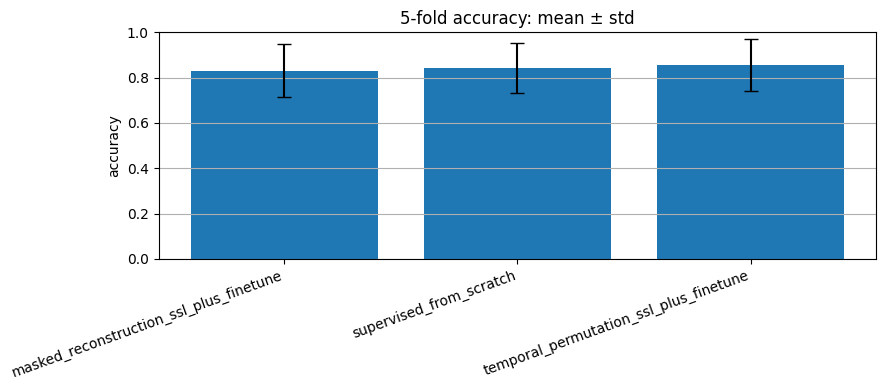

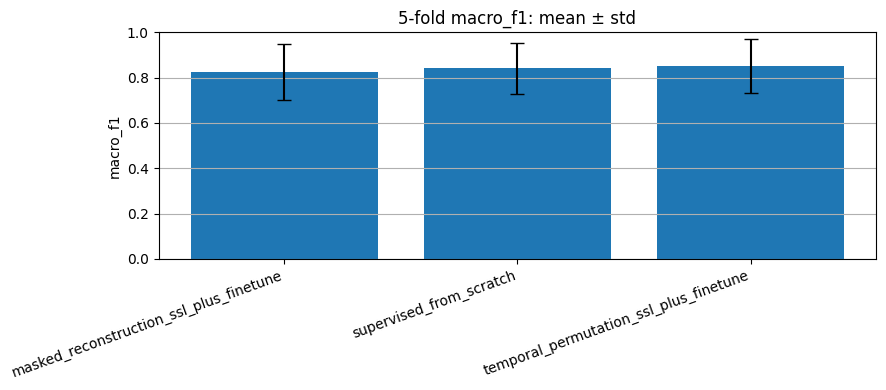

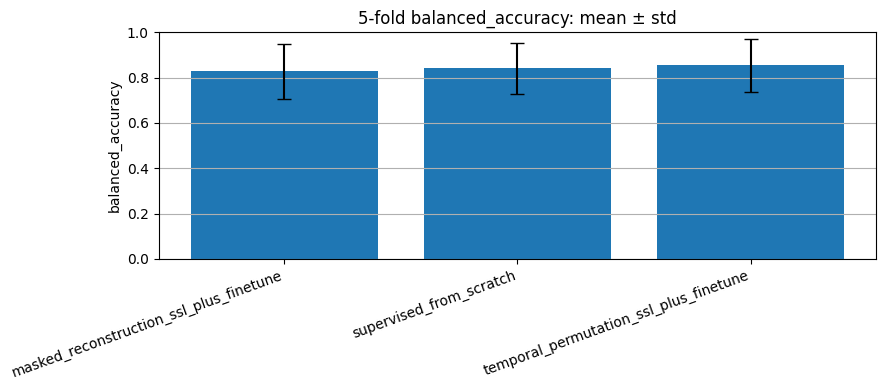

In [14]:
metrics = ["accuracy", "macro_f1", "balanced_accuracy"]

for metric in metrics:
    plt.figure(figsize=(9, 4))

    means = summary_flat[f"{metric}_mean"]
    stds = summary_flat[f"{metric}_std"]
    labels = summary_flat["model"]

    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.ylim(0, 1)
    plt.title(f"5-fold {metric}: mean ± std")
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

model,masked_minus_supervised,temporal_minus_supervised
fold,,
0,-0.031438,0.001383
1,0.002795,0.001649
2,-0.004059,0.010342
3,-0.036521,0.037445
4,-0.009488,0.000996


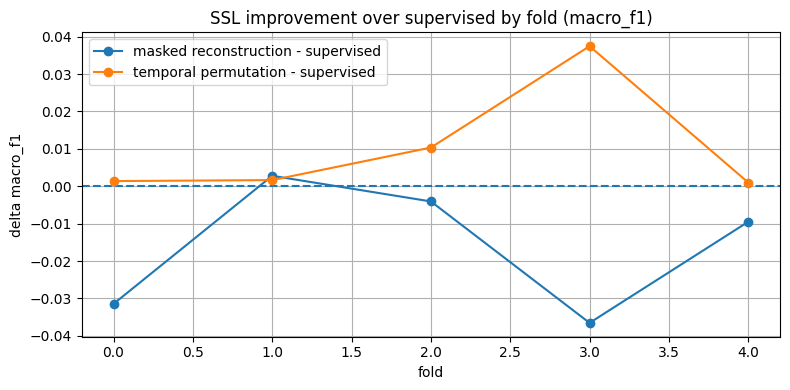

In [ ]:
metric = "macro_f1"

pivot = results.pivot(index="fold", columns="model", values=metric)

pivot["masked_minus_supervised"] = (
    pivot["masked_reconstruction_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

pivot["temporal_minus_supervised"] = (
    pivot["temporal_permutation_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

display(pivot[["masked_minus_supervised", "temporal_minus_supervised"]])

plt.figure(figsize=(8, 4))
plt.axhline(0, linestyle="--")

plt.plot(
    pivot.index,
    pivot["masked_minus_supervised"],
    marker="o",
    label="masked reconstruction - supervised",
)

plt.plot(
    pivot.index,
    pivot["temporal_minus_supervised"],
    marker="o",
    label="temporal permutation - supervised",
)

plt.title(f"SSL improvement over supervised by fold ({metric})")
plt.xlabel("fold")
plt.ylabel(f"delta {metric}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

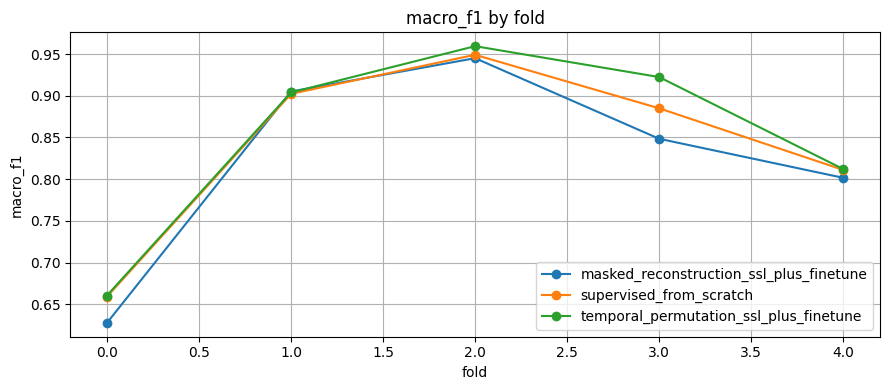

In [15]:
metric = "macro_f1"

plt.figure(figsize=(9, 4))

for model_name, group in results.groupby("model"):
    group = group.sort_values("fold")
    plt.plot(group["fold"], group[metric], marker="o", label=model_name)

plt.title(f"{metric} by fold")
plt.xlabel("fold")
plt.ylabel(metric)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/t3/4qj_4k256mxg4l2py__407l00000gn/T/ipykernel_82755/3788594701.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=models)


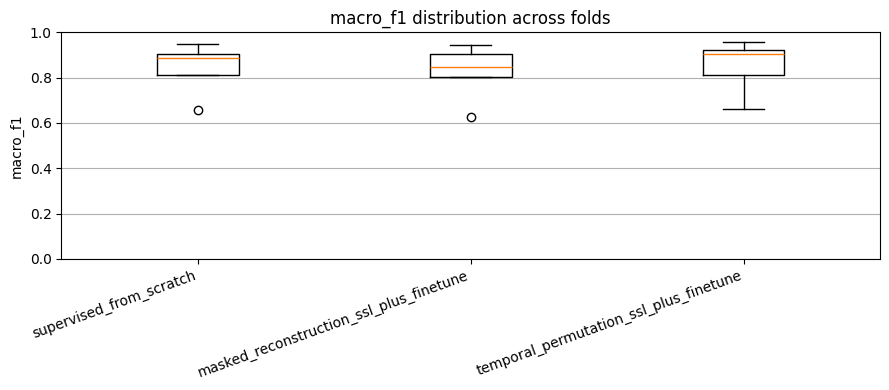

In [16]:
metric = "macro_f1"

models = results["model"].unique()
data_to_plot = [
    results.loc[results["model"] == model, metric].values
    for model in models
]

plt.figure(figsize=(9, 4))
plt.boxplot(data_to_plot, labels=models)
plt.ylim(0, 1)
plt.title(f"{metric} distribution across folds")
plt.ylabel(metric)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

model,masked_minus_supervised,temporal_minus_supervised
fold,,
0,-0.031438,0.001383
1,0.002795,0.001649
2,-0.004059,0.010342
3,-0.036521,0.037445
4,-0.009488,0.000996


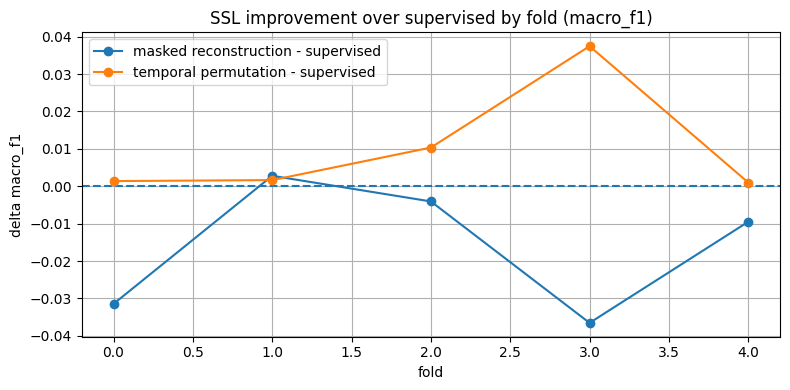

In [ ]:
metric = "macro_f1"

pivot = results.pivot(index="fold", columns="model", values=metric)

pivot["masked_minus_supervised"] = (
    pivot["masked_reconstruction_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

pivot["temporal_minus_supervised"] = (
    pivot["temporal_permutation_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

display(pivot[["masked_minus_supervised", "temporal_minus_supervised"]])

plt.figure(figsize=(8, 4))
plt.axhline(0, linestyle="--")

plt.plot(
    pivot.index,
    pivot["masked_minus_supervised"],
    marker="o",
    label="masked reconstruction - supervised",
)

plt.plot(
    pivot.index,
    pivot["temporal_minus_supervised"],
    marker="o",
    label="temporal permutation - supervised",
)

plt.title(f"SSL improvement over supervised by fold ({metric})")
plt.xlabel("fold")
plt.ylabel(f"delta {metric}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

model,masked_reconstruction_ssl_plus_finetune,supervised_from_scratch,temporal_permutation_ssl_plus_finetune
fold,,,
0,0.627783,0.659221,0.660604
1,0.905049,0.902254,0.903903
2,0.945016,0.949075,0.959417
3,0.848439,0.884959,0.922405
4,0.801654,0.811142,0.812138


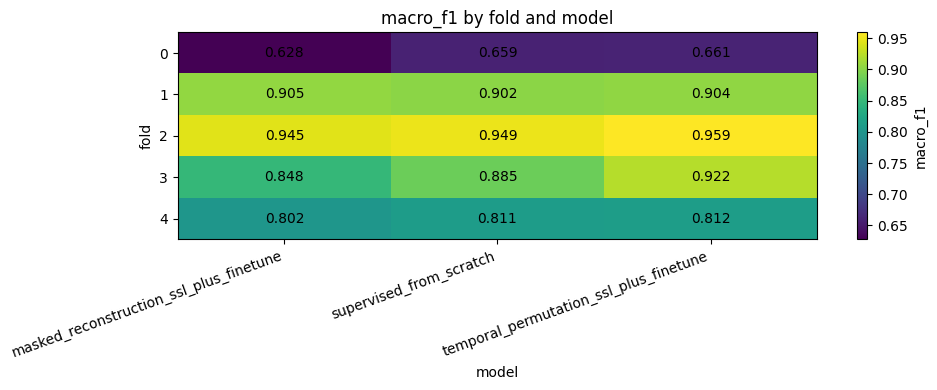

In [17]:
metric = "macro_f1"

heatmap_df = results.pivot(index="fold", columns="model", values=metric)
display(heatmap_df)

plt.figure(figsize=(10, 4))
plt.imshow(heatmap_df.values, aspect="auto")
plt.colorbar(label=metric)

plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=20, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        plt.text(j, i, f"{heatmap_df.values[i, j]:.3f}", ha="center", va="center")

plt.title(f"{metric} by fold and model")
plt.xlabel("model")
plt.ylabel("fold")
plt.tight_layout()
plt.show()

model,masked_minus_supervised,temporal_minus_supervised
fold,,
0,-0.031438,0.001383
1,0.002795,0.001649
2,-0.004059,0.010342
3,-0.036521,0.037445
4,-0.009488,0.000996


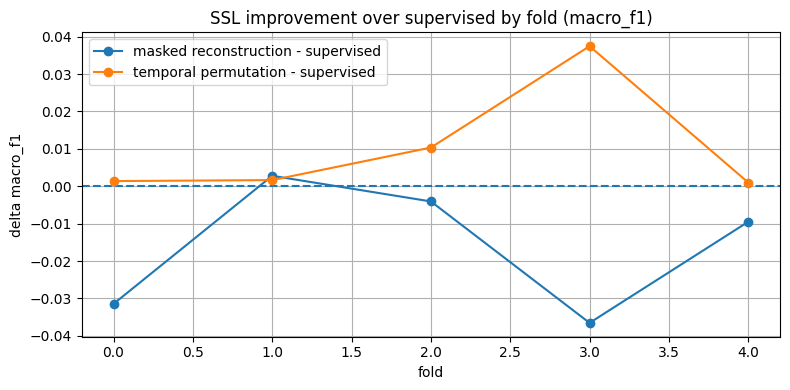

In [18]:
metric = "macro_f1"

pivot = results.pivot(index="fold", columns="model", values=metric)

pivot["masked_minus_supervised"] = (
    pivot["masked_reconstruction_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

pivot["temporal_minus_supervised"] = (
    pivot["temporal_permutation_ssl_plus_finetune"]
    - pivot["supervised_from_scratch"]
)

display(pivot[["masked_minus_supervised", "temporal_minus_supervised"]])

plt.figure(figsize=(8, 4))
plt.axhline(0, linestyle="--")

plt.plot(
    pivot.index,
    pivot["masked_minus_supervised"],
    marker="o",
    label="masked reconstruction - supervised",
)

plt.plot(
    pivot.index,
    pivot["temporal_minus_supervised"],
    marker="o",
    label="temporal permutation - supervised",
)

plt.title(f"SSL improvement over supervised by fold ({metric})")
plt.xlabel("fold")
plt.ylabel(f"delta {metric}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Визуализации помогают интерпретировать результаты эксперимента.

Bar plots с mean ± std показывают среднее качество и разброс по folds. Line plot `macro_f1 by fold` показывает, как меняется качество каждой модели на разных validation-группах. Boxplot показывает распределение качества по folds. Heatmap позволяет быстро увидеть, на каких folds какая модель работает лучше. График `SSL improvement over supervised` показывает разницу между SSL-подходами и supervised baseline на каждом fold.

По этим графикам видно, что temporal permutation чаще даёт небольшой положительный эффект относительно supervised baseline, а masked reconstruction чаще не улучшает качество. Также видно, что fold 0 является наиболее сложным, а качество существенно зависит от состава validation participants.

# Общий вывод

В третьем ноутбуке был выполнен основной эксперимент по сравнению supervised baseline и двух простых self-supervised подходов для классификации беговых движений по IMU-сигналам.

Эксперимент проводился на пяти заранее подготовленных group-wise folds. Разбиение было построено по `group_id`, поэтому одна и та же группа участника не попадала одновременно в train и validation. Это защищает оценку от data leakage и делает эксперимент более честным, чем случайное разбиение по окнам.

В качестве базовой архитектуры использовался 1D-CNN/FCN encoder. Он принимает окно IMU-сигнала формы `[6, 52]`, где 6 — это каналы акселерометра и гироскопа, а 52 — длина окна во времени. Для всех подходов использовался один и тот же encoder, что делает сравнение supervised и SSL-подходов более корректным.

Были обучены и сравнены три варианта:

1. `supervised_from_scratch` — обычное supervised-обучение классификатора с нуля;
2. `masked_reconstruction_ssl_plus_finetune` — SSL-pretraining через восстановление замаскированных timestep, затем fine-tuning на классификацию;
3. `temporal_permutation_ssl_plus_finetune` — SSL-pretraining через определение нарушения временного порядка сегментов, затем fine-tuning на классификацию.

Fine-tuning используется только в SSL-подходах, потому что там encoder сначала обучается на pretext-задаче без labels, а затем переносится в downstream-классификатор. Supervised baseline обучается сразу на labels с нуля, поэтому это не fine-tuning.

Итоговые результаты по 5 folds:

`temporal_permutation_ssl_plus_finetune` показал лучший средний результат:

`accuracy_mean ≈ 0.855`, `macro_f1_mean ≈ 0.852`, `balanced_accuracy_mean ≈ 0.854`.

Supervised baseline получил:

`accuracy_mean ≈ 0.843`, `macro_f1_mean ≈ 0.841`, `balanced_accuracy_mean ≈ 0.841`.

Masked reconstruction получил:

`accuracy_mean ≈ 0.830`, `macro_f1_mean ≈ 0.826`, `balanced_accuracy_mean ≈ 0.828`.

Таким образом, temporal permutation SSL дала небольшое улучшение относительно supervised baseline. Разница по macro-F1 составляет примерно 1 процентный пункт. Это не очень большое, но положительное улучшение. Masked reconstruction в текущей конфигурации не дала устойчивого выигрыша и оказалась хуже supervised baseline.

Интерпретация результата следующая: temporal permutation лучше согласуется с природой IMU-сигналов, потому что беговые движения имеют выраженную временную структуру и порядок фаз движения важен для классификации. Masked reconstruction, наоборот, может учить модель восстанавливать локальную форму сигнала, но не обязательно выделять признаки, полезные для различения классов движений.

Стандартные отклонения по folds достаточно большие. Это означает, что качество сильно зависит от того, какие участники попали в validation. Такой эффект ожидаем для небольшого датасета с человеческими движениями: разные участники могут выполнять упражнения с разной скоростью, амплитудой и техникой.

Основной итог эксперимента: для текущего MVP лучший результат показал `temporal_permutation_ssl_plus_finetune`. Self-supervised pretraining может быть полезен для классификации беговых движений по IMU-сигналам, но эффект зависит от выбранной pretext-задачи. Не всякая SSL-задача автоматически улучшает downstream-классификацию.

Ограничения текущего эксперимента:

1. используется только один фиксированный сенсор `sensor_idx = 0`;
2. анатомическое расположение сенсора явно не известно;
3. нет отдельной финальной test-выборки;
4. используется один random seed;
5. не выполнялся подбор window size, overlap и гиперпараметров;
6. не использовались sensor fusion и другие SSL-задачи, например `arrow-of-time` или `warping`.

Для MVP текущий результат можно считать завершённым: построен полный pipeline от подготовленных окон до 5-fold оценки моделей, реализован supervised baseline, две SSL-задачи, fine-tuning, метрики mean ± std и визуальный анализ результатов.